In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import importlib
import unet
importlib.reload(unet)
from unet import build_unet
from unet import load_preprocess
from mobile_u_net import load_preprocess_mobilenet
from mobile_u_net import build_mobile_u_net

In [3]:
image_ds = tf.data.Dataset.list_files("data/kitti/training/image_2/*.png", shuffle=False)
mask_ds = tf.data.Dataset.list_files("data/kitti/training/semantic/*.png", shuffle=False)
dataset = tf.data.Dataset.zip((image_ds, mask_ds))

I0000 00:00:1777019065.343401 21192532 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1777019065.343420 21192532 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
dataset = dataset.map(load_preprocess_mobilenet)

In [5]:
batch_size = 8
train_ds = dataset.take(160).shuffle(160).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(160).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [6]:
model = build_mobile_u_net((128,384, 3), 20)
model.summary()

/Users/kuzeyaldemir/Projects/drive-vision/mobile_u_net.py:32: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobile_net = tf.keras.applications.MobileNetV2(


Model: "mobile_u_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobile_net          │ [(None, 64, 192,  │  2,257,984 │ input_layer[0][0] │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 96, 144), (None,  │            │                   │
│                     │ 16, 48, 192),     │            │                   │
│                     │ (None, 8, 24,     │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 12, 1280)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 24,     │  2,621,952 │ mobile_net[0][4]  │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 24,     │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1088)             │            │ mobile_net[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 24,     │  5,014,016 │ concatenate[0][0] │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 24,     │  2,359,808 │ conv2d[0][0]      │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 48,    │    524,544 │ conv2d_1[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 48,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 448)              │            │ mobile_net[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 48,    │  1,032,448 │ concatenate_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 48,    │    590,080 │ conv2d_2[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 96,    │    131,200 │ conv2d_3[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 96,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 272)              │            │ mobile_net[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 96,    │    313,472 │ concatenate_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 96,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 64, 192,   │     32,832 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                 

 Total params: 15,199,892 (57.98 MB)

 Trainable params: 12,941,908 (49.37 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        'accuracy',
        tf.keras.metrics.MeanIoU(num_classes=20, sparse_y_pred=False, ignore_class=19, name='miou')
    ]
)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[tf.keras.callbacks.TensorBoard(log_dir='logs/mobilenet_frozen_skip_lr0.001')]
)

model.save('checkpoints/mobilenet_frozen_skip_20epochs.keras')

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 309ms/step - accuracy: 0.2876 - loss: 2.3379 - miou: 0.0262 - val_accuracy: 0.4168 - val_loss: 2.1034 - val_miou: 0.0426
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 242ms/step - accuracy: 0.4904 - loss: 1.7812 - miou: 0.0612 - val_accuracy: 0.5927 - val_loss: 1.5474 - val_miou: 0.0982
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step - accuracy: 0.6151 - loss: 1.3166 - miou: 0.1086 - val_accuracy: 0.6161 - val_loss: 1.3327 - val_miou: 0.1159
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step - accuracy: 0.6620 - loss: 1.1040 - miou: 0.1342 - val_accuracy: 0.6987 - val_loss: 1.1301 - val_miou: 0.1625
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - accuracy: 0.7032 - loss: 0.9951 - miou: 0.1618 - val_accuracy: 0.7277 - val_loss: 1.0092 - val_miou: 0.1993
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - accuracy: 0.7555 - loss: 0.8533 - miou: 0.1923 - val_accuracy: 0.7401 - val_loss: 0.9250 - val_miou: 0.1908
Epoch 7/20
20/20 ━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9995711..1.0].


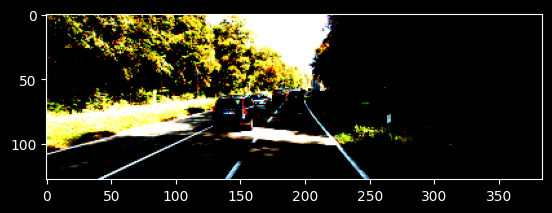

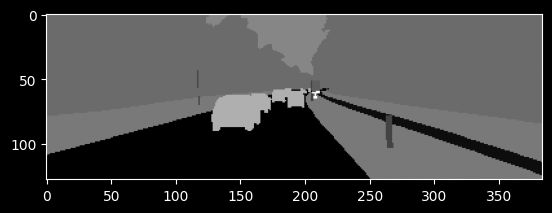

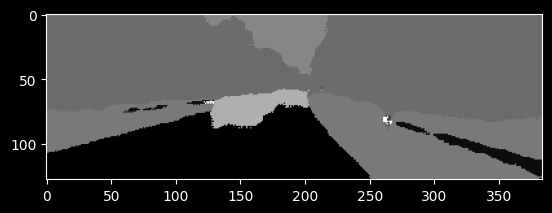

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


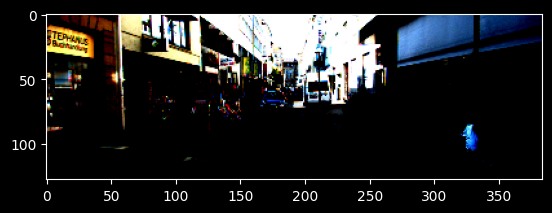

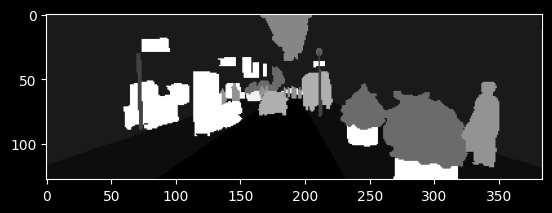

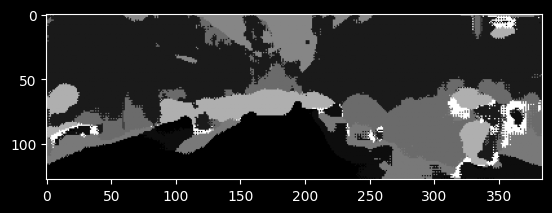

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.97083336..1.0].


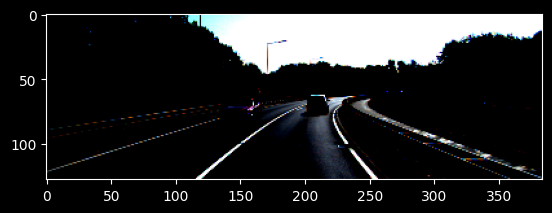

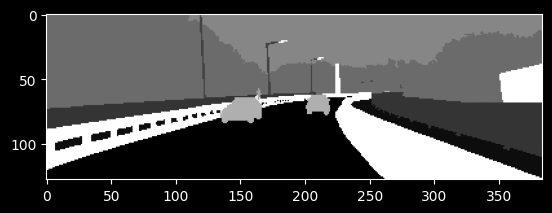

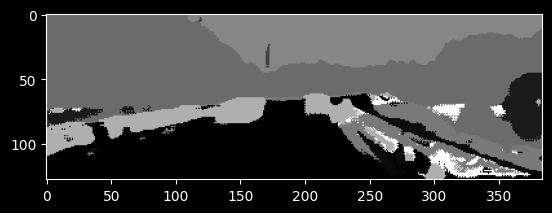

In [9]:
for image, mask in val_ds.take(3):
    prediction = model.predict(image)
    predicted_mask = tf.argmax(prediction, axis=-1)

    plt.imshow(image[0])
    plt.show()
    plt.imshow(tf.squeeze(mask[0]), cmap='gray')
    plt.show()
    plt.imshow(predicted_mask[0], cmap='gray')
    plt.show()